# Deep Learning for Computer Vision:  HW 5

## Computer Science: COMS W 4995 006

## Due: November 18, 2021

### Problem: Telling Cats from Dogs using VGG16

Here you will build a classifier that can distinguish between pictures of dogs and cats. You will use a ConvNet (VGG16) that was pre-trained ImageNet. Your task will be to re-architect the network to solve your problem. You are required to do this in Pytorch or Tensorflow. To do this you will:
0. Make a training, validation, and test sets for your dataset by using images from the link below, with 10,000 images of cats and 10,000 images of dogs. Use 8,000 images of each category for traning, 1,000 of each category for validation, 1,000 images of each category for testing. You are to randomly shuffle the data and choose the splits yourself.  
1. Take VGG16 network architecture. See https://pytorch.org/vision/stable/models.html.
2. Load in the pre-trained weights. See again https://pytorch.org/vision/stable/models.html. 
3. Add a fully connected layer followed by a final sigmoid layer **to replace** the last fully connected layer and 1000 category softmax layer that was used when the network was trained on ImageNet.
4. Freeze all layers except the last two that you added.
5. Fine-tune the network on your cats vs. dogs image data.
6. Evaluate the accuracy on the test set.
7. Unfreeze all layers.
8. Continue fine-tuning the network on your cats vs. dogs image data.
9. Evaluate the accuracy on the test set.
10. Use your validation set throughout to decide on when to stop training the network at various stages.
11. Comment your code and make sure to include accuracy, a few sample mistakes, and anything else you would like to add.
12. Experiment with what you keep and what you replace as part of your network surgery. Does the training work better if you do not remove the last fully connected layer or keep it?
13. Try this on another network like ResNet.

Downloads:
1. You can get your image data from:
https://www.kaggle.com/c/dogs-vs-cats/data. 

2. You can get your VGG16 pre-trained network from https://pytorch.org/vision/stable/models.html

You can either do this in Pytorch or Tensorflow. Part of the assignment is learning to navigate deep learning frameworks by figuring out how to load, modify, and train an existing network. 

In [2]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import math
import sys

In [69]:
train_data_dir = './data/train'
validation_data_dir = './data/validation'
train_samples = 20000
validation_samples = 2000
batch_size = 32

In [7]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), 
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) ] )

In [70]:
training_dataset = torchvision.datasets.ImageFolder(root=train_data_dir, transform=transform)
validation_dataset = torchvision.datasets.ImageFolder(root = validation_data_dir, transform=transform)

training_data_loader = torch.utils.data.DataLoader(training_dataset, batch_size=batch_size, shuffle=True, num_workers=4)
validation_data_loader = torch.utils.data.DataLoader(validation_dataset, batch_size=batch_size, shuffle=True, num_workers=4)

In [28]:
#Loading pretrained model
vgg16 = models.vgg16(pretrained=True)
vgg16_head = nn.Sequential(*(list(vgg16.children())[:-1])) # remove the classification part of vgg 16
print(vgg16_head)

Sequential(
  (0): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1

In [42]:
#Inherit from pretrained vgg16

class my_vgg16(nn.Module):

    def __init__(self, pretrained_CNN):
        super(my_vgg16, self).__init__()
        self.batch_size=32
        self.vgg16_head = pretrained_CNN
        
        #Add a fully connected layer followed by a final sigmoid layer
        self.fully_connected_layer = nn.Linear(in_features=25088, out_features=1, bias=True) 
        self.sigmoid = nn.Sigmoid()
        self.final_classification_layer = nn.Sequential(self.fully_connected_layer, self.sigmoid)

    def forward(self, x):
        x = self.vgg16_head(x)
        x = torch.reshape(x, (-1, 25088) )
        x = self.final_classification_layer(x)
        return x

In [43]:
model = my_vgg16(vgg16_head)
print(model)

my_vgg16(
  (vgg16_head): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (3): ReLU(inplace=True)
      (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (6): ReLU(inplace=True)
      (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): ReLU(inplace=True)
      (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): ReLU(inplace=True)
      (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (13): ReLU(inplace=True)
      (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (15): ReLU(inplace=True)
      

In [65]:
# freeze all layers except for the final 2 layers
for name, param in model.named_parameters():
    if name is "final_classification_layer":
        param.requires_grad = True
    else:
        param.requires_grad = False

for param in list(model.final_classification_layer.parameters()) :
    param.requires_grad= True
    print(param.requires_grad)

True
True


In [66]:
import torch.optim as optim
criterion = nn.BCELoss() # choosing Binary cross entropy loss
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

In [62]:
device = None 
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using {device}")


Using cpu


In [67]:
def train(model, num_epochs):
    model.to(device)
    
    for epoch in range(num_epochs):
        epoch_loss = 0
        counter = 0
        
        for i, data in enumerate(training_data_loader, 0):
            inputs, labels = data
            labels = labels.type(torch.FloatTensor)
            inputs = inputs.to(device)
            labels = labels.to(device)
    
            #Forward propogation
            predictions = model(inputs)
            labels = labels.reshape(predictions.shape)
            
            optimizer.zero_grad()


            loss = criterion(predictions, labels)
            loss.backward() #calculates the gradient
            #Backward propogation
            optimizer.step() 
 
            counter+=1
            epoch_loss += loss.item()
            if i%20 == 0:
                print(f'Epoch {epoch+1}, Batch {i+1}, loss: {epoch_loss/counter}')
                running_loss=0

In [71]:
train(model, 5)

Epoch 1, Batch 1, loss: 0.0007493128068745136
Epoch 1, Batch 21, loss: 0.17686459877239985
Epoch 1, Batch 41, loss: 0.1140190608538233
Epoch 1, Batch 61, loss: 0.09173267068614283
Epoch 1, Batch 81, loss: 0.08166233645601163
Epoch 1, Batch 101, loss: 0.06983350867988583
Epoch 1, Batch 121, loss: 0.08876963195762223
Epoch 1, Batch 141, loss: 0.08496734994172042
Epoch 1, Batch 161, loss: 0.08177155306102069
Epoch 1, Batch 181, loss: 0.07630738982426105
Epoch 1, Batch 201, loss: 0.07273316373473664
Epoch 1, Batch 221, loss: 0.0679596918126206
Epoch 1, Batch 241, loss: 0.06439939162051868
Epoch 1, Batch 261, loss: 0.06164747122610435
Epoch 1, Batch 281, loss: 0.05904921398036535
Epoch 1, Batch 301, loss: 0.06825007371789255
Epoch 1, Batch 321, loss: 0.06674643494383661
Epoch 1, Batch 341, loss: 0.06557838052983224
Epoch 1, Batch 361, loss: 0.06372735393349237
Epoch 1, Batch 381, loss: 0.06205744376606392
Epoch 1, Batch 401, loss: 0.06011913489626006
Epoch 1, Batch 421, loss: 0.058881272831

Epoch 5, Batch 661, loss: 0.01559633810108942
Epoch 5, Batch 681, loss: 0.01516237754574006
Epoch 5, Batch 701, loss: 0.014816133109595184


In [72]:
torch.save(model.state_dict(), './vgg16_frozen.pth') #saving model weights
model.load_state_dict(torch.load('./vgg16_frozen.pth'))

<All keys matched successfully>

In [75]:
def validate(model):
    model.eval()
    correct=0
    incorrect=[]
    incorrect_predictions=[]
    actual_labels=[]

    counter=0 
    with torch.no_grad():
        for data in validation_data_loader:
            images, labels = data 
            labels = labels.type(torch.FloatTensor)
            images = images.to(device)
            labels = labels.to(device)
            
            #Forward propogation
            predictions = model(images)
            labels = labels.reshape(predictions.shape)
            
            dogs = predictions>=0.5
            predictions[dogs] = 1
            predictions[~dogs] = 0 
            
            counter+=1

          
            for i in range(len(predictions)):
                if predictions[i]==labels[i]:
                    correct += 1
                else: 
                    incorrect.append(images[i])
                    incorrect_predictions.append(predictions[i])
                    actual_labels.append(labels[i])


        accuracy= float(correct)/float(len(validation_data_loader.dataset))
        return accuracy, incorrect, incorrect_predictions, actual_labels

In [76]:
accuracy, incorrect, incorrect_predictions, actual_labels = validate(model)
print(f'Accuracy with frozen layers: {accuracy}')

Accuracy with frozen layers: 0.988011988011988


In [77]:
#unfreeze layers
for name, param in model.named_parameters():
    param.requires_grad = True

In [78]:
train(model, 2)

Epoch 1, Batch 1, loss: 0.0001959594083018601
Epoch 1, Batch 21, loss: 0.0006536636356464615
Epoch 1, Batch 41, loss: 0.07688466343809457
Epoch 1, Batch 61, loss: 0.05210465420701988
Epoch 1, Batch 81, loss: 0.039447809961831094
Epoch 1, Batch 101, loss: 0.032044888184716014
Epoch 1, Batch 121, loss: 0.02690590481169605
Epoch 1, Batch 141, loss: 0.023285800565965933
Epoch 1, Batch 161, loss: 0.02051246833473372
Epoch 1, Batch 181, loss: 0.01836719184137674
Epoch 1, Batch 201, loss: 0.032162160720787585
Epoch 1, Batch 221, loss: 0.029303534984295762
Epoch 1, Batch 241, loss: 0.02693319338748202
Epoch 1, Batch 261, loss: 0.024931451379590172
Epoch 1, Batch 281, loss: 0.02326376235918127
Epoch 1, Batch 301, loss: 0.02178567696918795
Epoch 1, Batch 321, loss: 0.020478158863486928
Epoch 1, Batch 341, loss: 0.019302507482309827
Epoch 1, Batch 361, loss: 0.018372389916060484
Epoch 1, Batch 381, loss: 0.017446499288204794
Epoch 1, Batch 401, loss: 0.01659922329880985
Epoch 1, Batch 421, loss: 

In [79]:
torch.save(model.state_dict(), './vgg16_unfrozen.pth') #saving model weights
model.load_state_dict(torch.load('./vgg16_unfrozen.pth'))

<All keys matched successfully>

In [80]:
validation_accuracy, incorrect_classifications, incorrect_predictions, actual_labels = validate(model)
print(f'Accuracy after unfreezing layers: {validation_accuracy}')

Accuracy after unfreezing layers: 0.9875124875124875


In [83]:
def show_image(image): # function to show an image
    image = image / 2 + 0.5     # unnormalize
    npimage = image.numpy()
    plt.imshow(np.transpose(npimage, (1, 2, 0)))
    plt.show()    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


No of incorrect classifications: 25


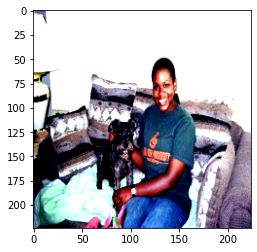

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Prediction: cat
Label: dog


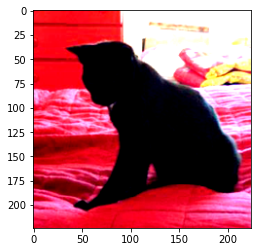

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Prediction: dog
Label: cat


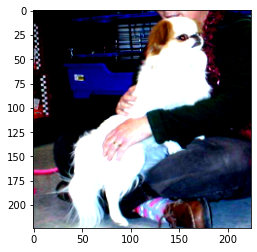

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Prediction: cat
Label: dog


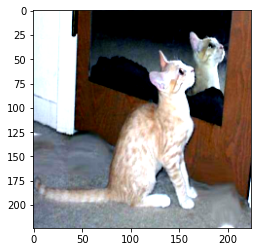

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Prediction: dog
Label: cat


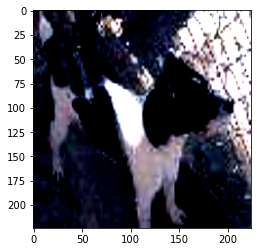

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Prediction: cat
Label: dog


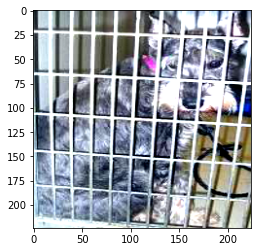

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Prediction: cat
Label: dog


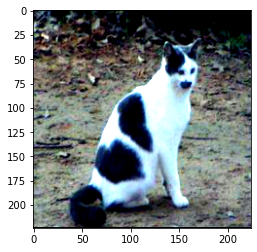

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Prediction: dog
Label: cat


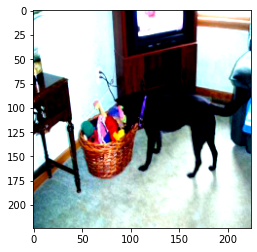

Prediction: cat
Label: dog


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


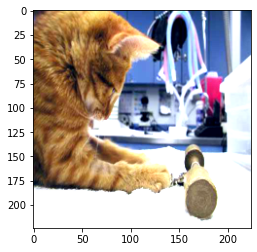

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Prediction: dog
Label: cat


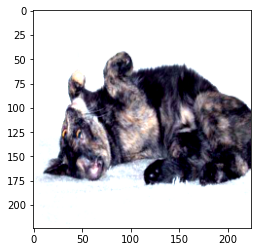

Prediction: dog
Label: cat


In [87]:
label_dict ={1:"dog", 0:"cat"}
print(f'No of incorrect classifications: {len(incorrect_classifications)}')

for i in range(10):
    show_image(incorrect_classifications[i])
    print(f'Prediction: {label_dict[int(incorrect_predictions[i])]}')
    print(f'Label: {label_dict[int(actual_labels[i])]}')